In [1]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np



In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("warcoder/potato-leaf-disease-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'potato-leaf-disease-dataset' dataset.
Path to dataset files: /kaggle/input/potato-leaf-disease-dataset


In [9]:
path = "/kaggle/input/potato-leaf-disease-dataset/Potato Leaf Disease Dataset in Uncontrolled Environment"
IMAGE_SIZE = 256
BATCH_SIZE = 32

In [10]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    directory=path,
    batch_size=32,
    image_size=(256,256),
    shuffle=True,
)

Found 3076 files belonging to 7 classes.


In [11]:
class_names = dataset.class_names
class_names

['Bacteria', 'Fungi', 'Healthy', 'Nematode', 'Pest', 'Phytopthora', 'Virus']

In [12]:
len(dataset)

97

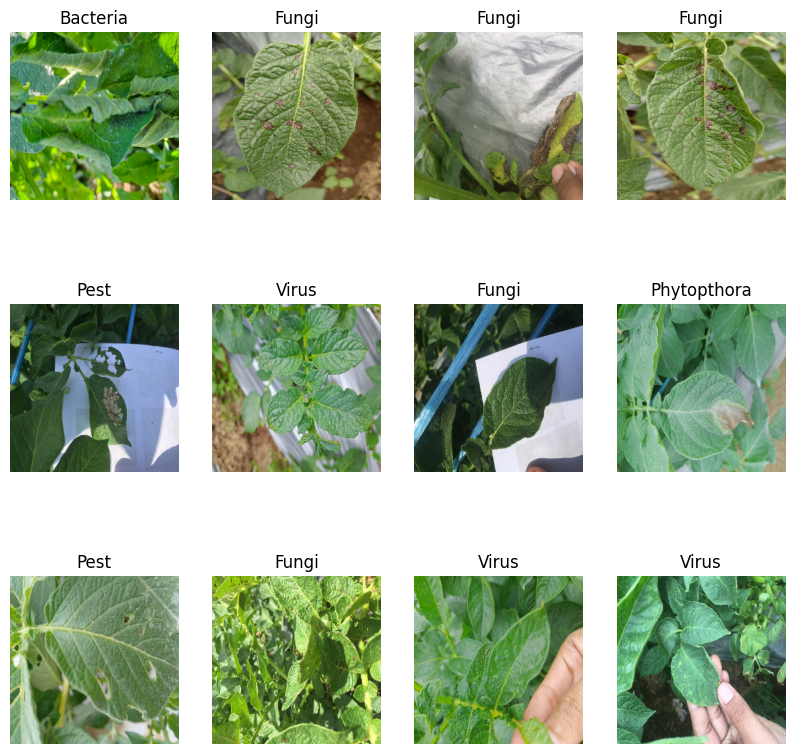

In [13]:
plt.figure(figsize=(10,10))
for image_batch, label_batch in dataset.take(1):
  for i in range(12):
    ax = plt.subplot(3,4,i+1)
    plt.imshow(image_batch[i].numpy().astype("uint8"))
    plt.title(class_names[label_batch[i]])
    plt.axis("off")


In [14]:
train_size = 0.8
len(dataset)*train_size

77.60000000000001

In [15]:
train_ds = dataset.take(77)
len(train_ds)

77

In [16]:
test_ds = dataset.skip(77)
len(test_ds)

20

In [17]:
val_size=0.1
len(dataset)*val_size

9.700000000000001

In [18]:
val_ds = test_ds.take(9)
len(val_ds)

9

In [19]:
test_ds = test_ds.skip(9)
len(test_ds)

11

In [20]:
def get_dataset_partitions(ds,train_split=0.8,test_split=0.1,val_split=0.1,shuffle=True,shuffle_size=10000):

  if shuffle:
    ds = ds.shuffle(shuffle_size,seed=12)

  train_ds = ds.take(int(len(ds)*train_split))
  remaining_ds = ds.skip(int(len(ds)*train_split))
  val_ds = remaining_ds.take(int(len(ds)*val_split))
  test_ds = remaining_ds.skip(int(len(ds)*val_split))
  return train_ds,val_ds,test_ds

In [21]:
train_ds, val_ds, test_ds = get_dataset_partitions(dataset, train_split=0.8, val_split=0.1, test_split=0.1)

In [22]:
len(train_ds)

77

In [23]:
len(test_ds)

11

In [24]:
len(val_ds)

9

In [25]:
train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [26]:
data_augmentation = tf.keras.Sequential([
    keras.layers.Resizing(IMAGE_SIZE,IMAGE_SIZE),
    keras.layers.Rescaling(1.0/255),
    keras.layers.RandomRotation(0.1),
    keras.layers.RandomZoom(0.1),
    keras.layers.RandomContrast(0.1),
    keras.layers.RandomFlip("horizontal_and_vertical")
])

In [27]:
model = keras.Sequential([
    data_augmentation,
    keras.layers.Conv2D(32,3,activation="relu"),
    keras.layers.MaxPooling2D(),
    keras.layers.Conv2D(64,3,activation="relu"),
    keras.layers.MaxPooling2D(),
    keras.layers.Conv2D(64,3,activation="relu"),
    keras.layers.MaxPooling2D(),
    keras.layers.Conv2D(64,3,activation="relu"),
    keras.layers.MaxPooling2D(),
    keras.layers.Conv2D(64,3,activation="relu"),
    keras.layers.MaxPooling2D(),
    keras.layers.Conv2D(64,3,activation="relu"),
    keras.layers.MaxPooling2D(),
    keras.layers.Flatten(),
    keras.layers.Dense(64,activation="relu"),
    keras.layers.Dense(7,activation="softmax")
])

model.build(input_shape=(32,IMAGE_SIZE,IMAGE_SIZE,3))

In [28]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (32, 254, 254, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (32, 127, 127, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (32, 125, 125, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (32, 62, 62, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (32, 60, 60, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (32, 30, 30, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (32, 28, 28, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (32, 14, 14, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (32, 12, 12, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (32, 6, 6, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (32, 4, 4, 64)         │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (32, 2, 2, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (32, 256)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (32, 64)               │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (32, 7)                │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 184,007 (718.78 KB)

 Trainable params: 184,007 (718.78 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
model.compile(
    optimizer="adam",
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"]
)

In [ ]:
history = model.fit(train_ds,epochs=10,batch_size=32,verbose=1,validation_data=val_ds)

Epoch 1/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 61s 367ms/step - accuracy: 0.2278 - loss: 1.8147 - val_accuracy: 0.2326 - val_loss: 1.8277
Epoch 2/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 49s 352ms/step - accuracy: 0.2323 - loss: 1.8024 - val_accuracy: 0.2292 - val_loss: 1.7797
Epoch 3/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 80s 338ms/step - accuracy: 0.2525 - loss: 1.7860 - val_accuracy: 0.2569 - val_loss: 1.8157
Epoch 4/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 84s 349ms/step - accuracy: 0.2718 - loss: 1.7292 - val_accuracy: 0.3507 - val_loss: 1.6447
Epoch 5/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 49s 352ms/step - accuracy: 0.3079 - loss: 1.6398 - val_accuracy: 0.3438 - val_loss: 1.6477
Epoch 6/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 100s 600ms/step - accuracy: 0.3366 - loss: 1.6047 - val_accuracy: 0.4132 - val_loss: 1.4737
Epoch 7/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 63s 341ms/step - accuracy: 0.3539 - loss: 1.5620 - val_accuracy: 0.3646 - val_loss: 1.4918
Epoch 8/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 49s 355ms/step - accuracy: 0.3834 - loss: 1.5019 - val_acc

In [ ]:
model.save("10epochspotato.keras")

**Training 10 epochs at a time**



In [ ]:
history2 = model.fit(train_ds,initial_epoch=10,epochs=20,batch_size=32,verbose=1,validation_data=val_ds)

Epoch 11/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 49s 353ms/step - accuracy: 0.4294 - loss: 1.3797 - val_accuracy: 0.4583 - val_loss: 1.3446
Epoch 12/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 80s 339ms/step - accuracy: 0.4491 - loss: 1.3459 - val_accuracy: 0.4885 - val_loss: 1.2905
Epoch 13/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 49s 349ms/step - accuracy: 0.4565 - loss: 1.3380 - val_accuracy: 0.5417 - val_loss: 1.1816
Epoch 14/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 100s 599ms/step - accuracy: 0.4745 - loss: 1.3026 - val_accuracy: 0.4826 - val_loss: 1.3470
Epoch 15/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 68s 599ms/step - accuracy: 0.4838 - loss: 1.2729 - val_accuracy: 0.4514 - val_loss: 1.3858
Epoch 16/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 82s 599ms/step - accuracy: 0.5008 - loss: 1.2258 - val_accuracy: 0.4931 - val_loss: 1.2671
Epoch 17/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 81s 601ms/step - accuracy: 0.5021 - loss: 1.2270 - val_accuracy: 0.4931 - val_loss: 1.2297
Epoch 18/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 50s 357ms/step - accuracy: 0.4860 - loss: 1.2786 -

In [ ]:
model.save("20epochspotato.keras")

In [ ]:
history2 = model.fit(train_ds,initial_epoch=20,epochs=30,batch_size=32,verbose=1,validation_data=val_ds)

Epoch 21/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 50s 362ms/step - accuracy: 0.5312 - loss: 1.1434 - val_accuracy: 0.5346 - val_loss: 1.1624
Epoch 22/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 50s 360ms/step - accuracy: 0.5489 - loss: 1.1428 - val_accuracy: 0.5521 - val_loss: 1.1522
Epoch 23/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 99s 600ms/step - accuracy: 0.5694 - loss: 1.0831 - val_accuracy: 0.5833 - val_loss: 1.0433
Epoch 24/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 51s 364ms/step - accuracy: 0.5666 - loss: 1.0999 - val_accuracy: 0.5556 - val_loss: 1.0584
Epoch 25/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 68s 599ms/step - accuracy: 0.5509 - loss: 1.1023 - val_accuracy: 0.5590 - val_loss: 1.1000
Epoch 26/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 81s 599ms/step - accuracy: 0.5920 - loss: 1.0416 - val_accuracy: 0.5972 - val_loss: 0.9882
Epoch 27/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 50s 356ms/step - accuracy: 0.5993 - loss: 1.0198 - val_accuracy: 0.6389 - val_loss: 0.9712
Epoch 28/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 80s 348ms/step - accuracy: 0.6096 - loss: 1.0145 - 

In [ ]:
model.save("30epochspotato.keras")

In [ ]:
history4 = model.fit(train_ds,initial_epoch=30,epochs=40,batch_size=32,verbose=1,validation_data=val_ds)

Epoch 31/40
77/77 ━━━━━━━━━━━━━━━━━━━━ 48s 350ms/step - accuracy: 0.6363 - loss: 0.9383 - val_accuracy: 0.6597 - val_loss: 0.9186
Epoch 32/40
77/77 ━━━━━━━━━━━━━━━━━━━━ 82s 345ms/step - accuracy: 0.6429 - loss: 0.9215 - val_accuracy: 0.5764 - val_loss: 0.9938
Epoch 33/40
77/77 ━━━━━━━━━━━━━━━━━━━━ 83s 354ms/step - accuracy: 0.6396 - loss: 0.9142 - val_accuracy: 0.6840 - val_loss: 0.8706
Epoch 34/40
77/77 ━━━━━━━━━━━━━━━━━━━━ 49s 353ms/step - accuracy: 0.6502 - loss: 0.9033 - val_accuracy: 0.6701 - val_loss: 0.8939
Epoch 35/40
77/77 ━━━━━━━━━━━━━━━━━━━━ 80s 339ms/step - accuracy: 0.6539 - loss: 0.8745 - val_accuracy: 0.6771 - val_loss: 0.8198
Epoch 36/40
77/77 ━━━━━━━━━━━━━━━━━━━━ 84s 354ms/step - accuracy: 0.6716 - loss: 0.8662 - val_accuracy: 0.7326 - val_loss: 0.7200
Epoch 37/40
77/77 ━━━━━━━━━━━━━━━━━━━━ 83s 356ms/step - accuracy: 0.6835 - loss: 0.8129 - val_accuracy: 0.7049 - val_loss: 0.8335
Epoch 38/40
77/77 ━━━━━━━━━━━━━━━━━━━━ 49s 356ms/step - accuracy: 0.6884 - loss: 0.8236 - 

In [ ]:
model.save("40epochspotato.keras")

In [ ]:
history5 = model.fit(train_ds,initial_epoch=40,epochs=50,batch_size=32,verbose=1,validation_data=val_ds)

Epoch 41/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 49s 352ms/step - accuracy: 0.7102 - loss: 0.7790 - val_accuracy: 0.6944 - val_loss: 0.7868
Epoch 42/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 49s 355ms/step - accuracy: 0.7032 - loss: 0.7993 - val_accuracy: 0.7188 - val_loss: 0.7253
Epoch 43/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 81s 342ms/step - accuracy: 0.7245 - loss: 0.7300 - val_accuracy: 0.7257 - val_loss: 0.7218
Epoch 44/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 102s 599ms/step - accuracy: 0.7360 - loss: 0.7009 - val_accuracy: 0.7674 - val_loss: 0.6688
Epoch 45/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 47s 337ms/step - accuracy: 0.7430 - loss: 0.6857 - val_accuracy: 0.7778 - val_loss: 0.6008
Epoch 46/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 103s 599ms/step - accuracy: 0.7447 - loss: 0.6907 - val_accuracy: 0.7500 - val_loss: 0.6811
Epoch 47/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 49s 353ms/step - accuracy: 0.7644 - loss: 0.6463 - val_accuracy: 0.7222 - val_loss: 0.7089
Epoch 48/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 46s 334ms/step - accuracy: 0.7532 - loss: 0.6563 

In [ ]:
model.save("50epochspotato.keras")

In [ ]:
history6 = model.fit(train_ds,initial_epoch=50,epochs=60,batch_size=32,verbose=1,validation_data=val_ds)

Epoch 51/60
77/77 ━━━━━━━━━━━━━━━━━━━━ 48s 349ms/step - accuracy: 0.7861 - loss: 0.5865 - val_accuracy: 0.8056 - val_loss: 0.5613
Epoch 52/60
77/77 ━━━━━━━━━━━━━━━━━━━━ 101s 600ms/step - accuracy: 0.7849 - loss: 0.5588 - val_accuracy: 0.7743 - val_loss: 0.5697
Epoch 53/60
77/77 ━━━━━━━━━━━━━━━━━━━━ 63s 348ms/step - accuracy: 0.7742 - loss: 0.5968 - val_accuracy: 0.8021 - val_loss: 0.5523
Epoch 54/60
77/77 ━━━━━━━━━━━━━━━━━━━━ 101s 598ms/step - accuracy: 0.7894 - loss: 0.5579 - val_accuracy: 0.7674 - val_loss: 0.5884
Epoch 55/60
77/77 ━━━━━━━━━━━━━━━━━━━━ 81s 599ms/step - accuracy: 0.7919 - loss: 0.5524 - val_accuracy: 0.8231 - val_loss: 0.5056
Epoch 56/60
77/77 ━━━━━━━━━━━━━━━━━━━━ 64s 351ms/step - accuracy: 0.8128 - loss: 0.5272 - val_accuracy: 0.8472 - val_loss: 0.4026
Epoch 57/60
77/77 ━━━━━━━━━━━━━━━━━━━━ 49s 351ms/step - accuracy: 0.8001 - loss: 0.5426 - val_accuracy: 0.7465 - val_loss: 0.6604
Epoch 58/60
77/77 ━━━━━━━━━━━━━━━━━━━━ 49s 353ms/step - accuracy: 0.8054 - loss: 0.5371 

In [ ]:
model.save("60epochspotato.keras")

In [ ]:
history8 = model.fit(train_ds,initial_epoch=60,epochs=80,batch_size=32,verbose=1,validation_data=val_ds)

Epoch 61/80
77/77 ━━━━━━━━━━━━━━━━━━━━ 49s 353ms/step - accuracy: 0.8062 - loss: 0.5053 - val_accuracy: 0.7778 - val_loss: 0.6663
Epoch 62/80
77/77 ━━━━━━━━━━━━━━━━━━━━ 100s 599ms/step - accuracy: 0.8075 - loss: 0.5009 - val_accuracy: 0.8611 - val_loss: 0.4042
Epoch 63/80
77/77 ━━━━━━━━━━━━━━━━━━━━ 63s 339ms/step - accuracy: 0.8099 - loss: 0.5242 - val_accuracy: 0.7708 - val_loss: 0.5745
Epoch 64/80
77/77 ━━━━━━━━━━━━━━━━━━━━ 49s 351ms/step - accuracy: 0.8214 - loss: 0.4740 - val_accuracy: 0.7951 - val_loss: 0.5347
Epoch 65/80
77/77 ━━━━━━━━━━━━━━━━━━━━ 101s 599ms/step - accuracy: 0.8227 - loss: 0.4894 - val_accuracy: 0.8472 - val_loss: 0.4062
Epoch 66/80
77/77 ━━━━━━━━━━━━━━━━━━━━ 62s 341ms/step - accuracy: 0.7984 - loss: 0.5456 - val_accuracy: 0.8472 - val_loss: 0.4764
Epoch 67/80
77/77 ━━━━━━━━━━━━━━━━━━━━ 85s 380ms/step - accuracy: 0.8210 - loss: 0.4902 - val_accuracy: 0.7812 - val_loss: 0.5405
Epoch 68/80
77/77 ━━━━━━━━━━━━━━━━━━━━ 99s 599ms/step - accuracy: 0.8206 - loss: 0.4726 

In [ ]:
model.save("80epochspotato.keras")

In [ ]:
history100 = model.fit(train_ds,initial_epoch=80,epochs=100,batch_size=32,verbose=1,validation_data=val_ds)

Epoch 81/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 49s 349ms/step - accuracy: 0.8678 - loss: 0.3514 - val_accuracy: 0.8785 - val_loss: 0.3501
Epoch 82/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 99s 599ms/step - accuracy: 0.8608 - loss: 0.3880 - val_accuracy: 0.8611 - val_loss: 0.3847
Epoch 83/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 48s 348ms/step - accuracy: 0.8465 - loss: 0.4468 - val_accuracy: 0.8654 - val_loss: 0.3486
Epoch 84/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 82s 354ms/step - accuracy: 0.8709 - loss: 0.3546 - val_accuracy: 0.8750 - val_loss: 0.3409
Epoch 85/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 81s 340ms/step - accuracy: 0.8764 - loss: 0.3312 - val_accuracy: 0.8542 - val_loss: 0.4588
Epoch 86/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 102s 599ms/step - accuracy: 0.8563 - loss: 0.3782 - val_accuracy: 0.8715 - val_loss: 0.3824
Epoch 87/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 67s 600ms/step - accuracy: 0.8742 - loss: 0.3349 - val_accuracy: 0.8299 - val_loss: 0.5045
Epoch 88/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 49s 352ms/step - accuracy: 0.8904 - loss: 

In [ ]:
model.save("100epochspotato.keras")

In [ ]:
model.evaluate(test_ds)

11/11 ━━━━━━━━━━━━━━━━━━━━ 22s 21ms/step - accuracy: 0.8864 - loss: 0.2787


[0.2787342965602875, 0.8863636255264282]

In [30]:
model = keras.models.load_model("100epochspotato.keras")

firs image to predict
actual label Virus
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
predicted label Virus


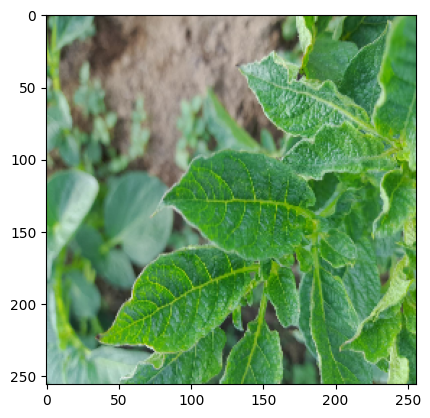

In [35]:
for images_batch, labels_batch in test_ds.take(1):
  first_img = images_batch[15].numpy().astype("uint8")
  first_label = labels_batch[15]
  print("firs image to predict")
  plt.imshow(first_img)
  print("actual label",class_names[first_label])
  batch_prediction = model.predict(images_batch)
  print("predicted label",class_names[np.argmax(batch_prediction[15])])

In [37]:
def predict(model,img):
  img_array = tf.keras.preprocessing.image.img_to_array(images_batch[i].numpy())
  img_array = tf.expand_dims(img_array,0)

  predictions = model.predict(img_array)

  predicted_class = class_names[np.argmax(predictions[0])]
  confidence = round(100*(np.max(predictions[0])),2)
  return predicted_class, confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


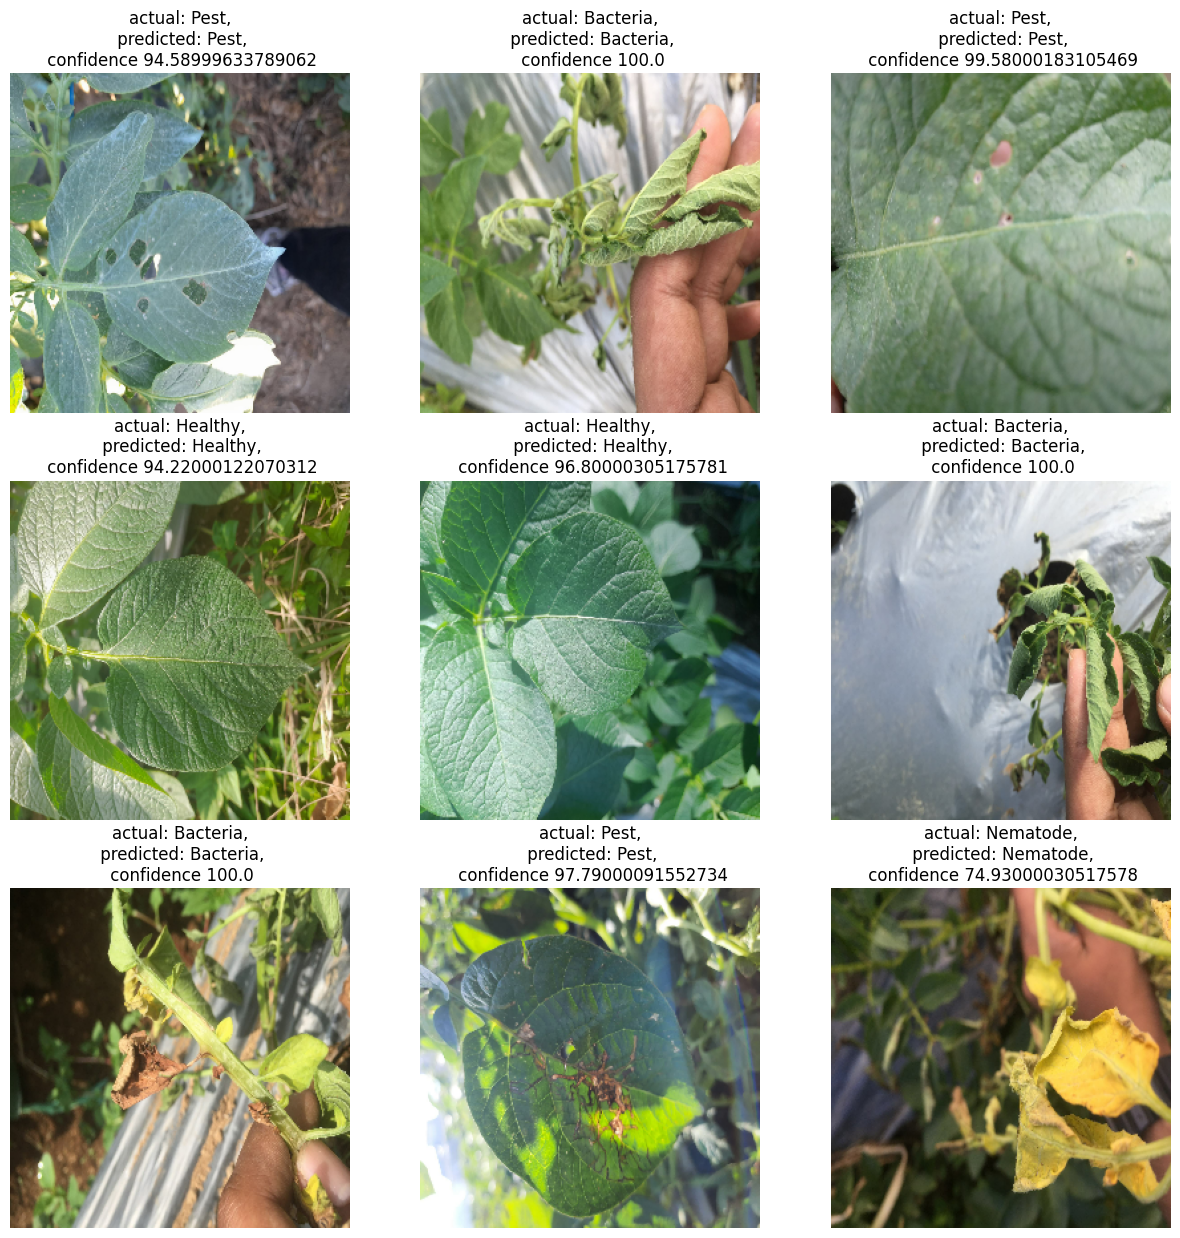

In [40]:
plt.figure(figsize=(15,15))
for images_batch, labels_batch in test_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3,3,i+1)
    plt.imshow(images_batch[i].numpy().astype("uint8"))
    actual_class = class_names[labels_batch[i]]


    predicted_class, confidence = predict(model,images_batch[i].numpy())
    plt.title(f"actual: {actual_class},\n predicted: {predicted_class},\n confidence {confidence}")

    plt.axis("off")

In [43]:
model.export("/content/model")

Saved artifact at '/content/model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  134233366390608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134233366391184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134233366391568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134233366390992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134233366391760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134233366392720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134233366393296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134233366393872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134233366394256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134233366392528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134233366394640: 